In [1]:
from pathlib import Path
import contextlib

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [14]:
results_fp = Path("./results/wind_extraction_jan_2024.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [23]:
results = pd.read_csv(results_fp).dropna(axis=1, how="all")
results = results[(results.Score != 0)]

In [24]:
results["classification"] = results.Score.map(
    {
        4: "Correct",
        33: "ROW",
        40: "PvNP",
        3: "Wrong",
        44: "Bad Scrape",
    }
)

In [25]:
correct_doc_compare = results[
    results["classification"] != "Bad Scrape"
].copy()

In [26]:
correct_doc_compare["ordinance_value_exists"] = 1
mask = (
    (correct_doc_compare["mult_value_interns"].isna())
    & (correct_doc_compare["value_interns"].isna())
)
correct_doc_compare.loc[mask, "ordinance_value_exists"] = 0

In [27]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)",
        "Intern value wrong, LLM correct"
    },
    "exists_report": {
        "Correct (exists)",
        "Intern value wrong, LLM correct",
    },
    "dne_report": {"Value does not exist but LLM reported it"},
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

In [28]:
def compute_llm_score(row):
    if row["ordinance_value_exists"] == 1:
        if row["classification"] in {"Correct", "ROW", "PvNP"}:
            return "Correct (exists)"
        if row[["mult_value_llm", "value_llm"]].isna().all():
            return "Value exists but LLM did not find"
        return "Value exists but LLM got it wrong"

    if row["classification"] in {"Correct", "ROW", "PvNP"}:
        return "Correct (DNE)"

    return "Value does not exist but LLM reported it"


correct_doc_compare["Score"] = correct_doc_compare.apply(
    compute_llm_score, axis=1
)
correct_doc_compare["Score"].value_counts()

Score
Correct (DNE)                               670
Correct (exists)                            325
Value exists but LLM did not find            42
Value does not exist but LLM reported it     34
Value exists but LLM got it wrong            34
Name: count, dtype: int64

In [29]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)",
        "Intern value wrong, LLM correct"
    },
    "exists_report": {
        "Correct (exists)",
        "Intern value wrong, LLM correct",
    },
    "dne_report": {"Value does not exist but LLM reported it"},
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

In [30]:
truth_labels_col = "ordinance_value_exists"

out = compute_stats(
    correct_doc_compare,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[325  76]
 [ 34 670]]
accuracy=90.05%, precision=82.70%, recall=81.05%, F1=81.86%


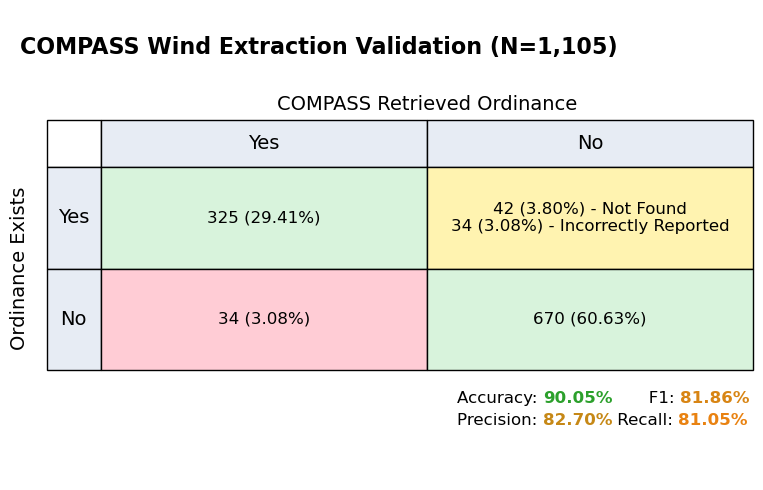

In [32]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare,
    score_cats,
    title="COMPASS Wind Extraction Validation",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Retrieved Ordinance",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "wind_validation_all_ordinances.png",
    color_scores=True,
)

In [35]:
all_stats = []
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    __, a, p, r, f1 = compute_stats(
        data, score_cats, truth_labels_col=truth_labels_col
    )
    num_values = data["ordinance_value_exists"].sum()
    num_found = (
        data["Score"].isin(
            score_cats["exists_report"]
            | score_cats["exists_bad_report"]
            | score_cats["dne_report"]
        )
    ).sum()
    num_found_correctly = (
        data["Score"].isin(score_cats["exists_report"])
    ).sum()

    all_stats.append(
        [
            feature,
            a * 100,
            p * 100,
            r * 100,
            num_values,
            num_found,
            num_found_correctly
        ]
    )

pra_breakdown = pd.DataFrame(
    all_stats,
    columns=[
        "feature",
        "Accuracy",
        "Precision",
        "Recall",
        "# non-null Ordinances",
        "# Ordinances reported by COMPASS",
        "# Ordinances correctly reported by COMPASS"
    ]
)

pra_breakdown.to_csv(out_dir / "pra_breakdown.csv", index=False)
pra_breakdown

,feature,Accuracy,Precision,Recall,# non-null Ordinances,# Ordinances reported by COMPASS,# Ordinances correctly reported by COMPASS
0,struct (participating),91.764706,83.333333,76.923077,26,24,20
1,struct (non-participating),78.823529,78.260870,80.597015,67,69,54
2,pline (participating),92.941176,55.555556,71.428571,7,9,5
3,pline (non-participating),80.000000,80.519481,84.931507,73,77,62
4,roads,88.235294,86.153846,88.888889,63,65,56
5,rail,97.647059,88.888889,100.000000,16,18,16
6,trans,91.764706,90.000000,92.307692,39,40,36
7,water,94.117647,70.000000,63.636364,11,10,7
8,noise,84.705882,81.395349,81.395349,43,43,35
9,max height,90.588235,89.473684,73.913043,23,19,17


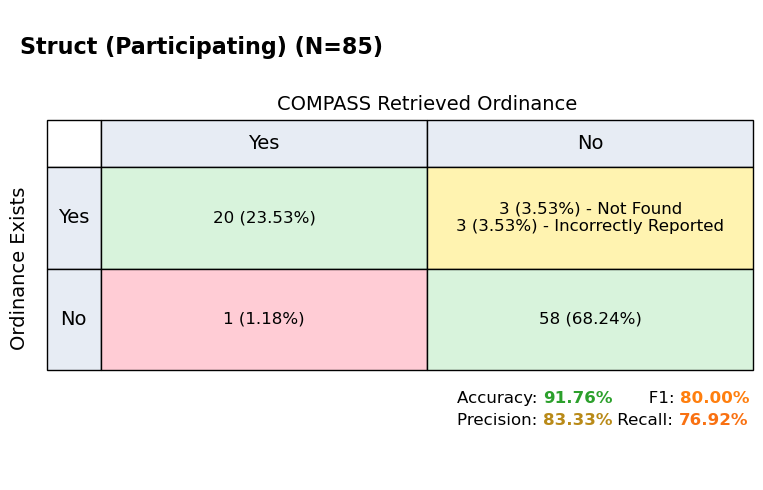

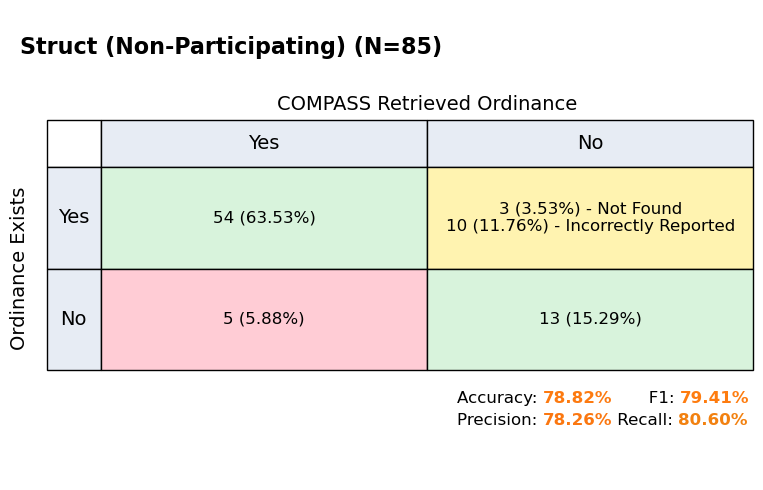

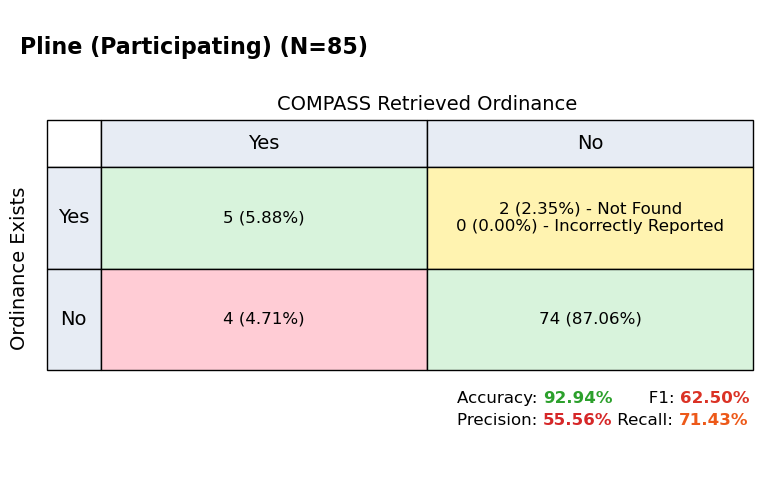

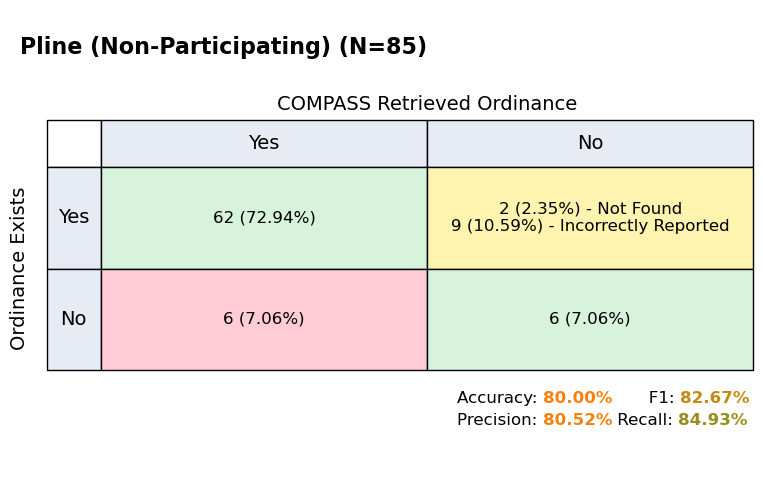

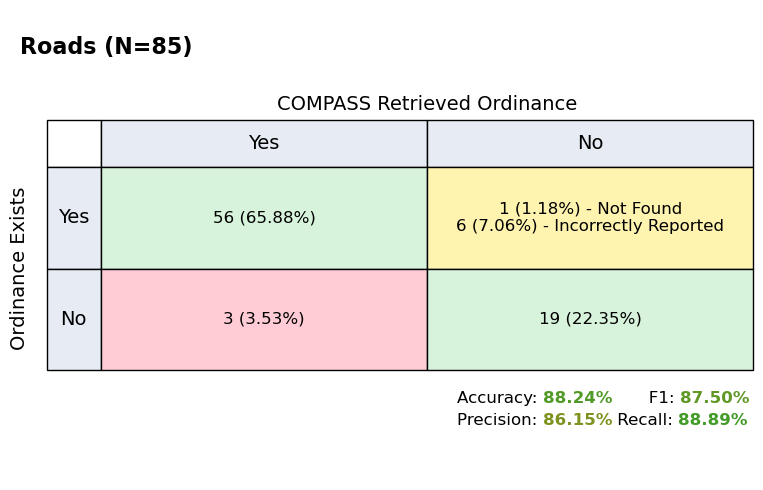

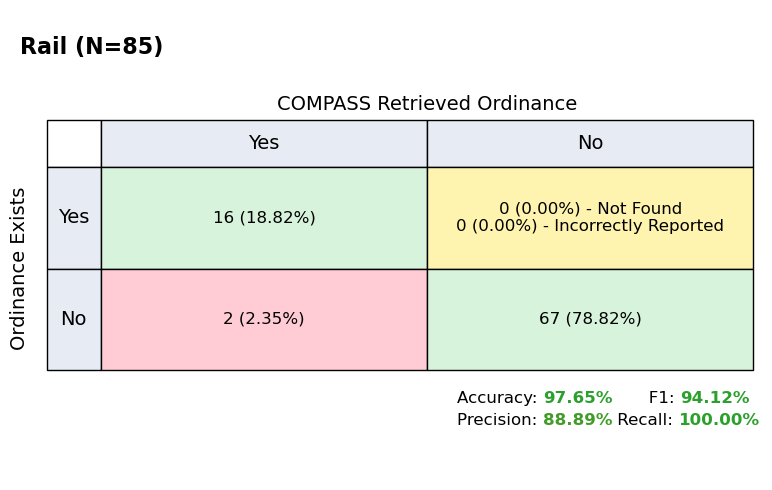

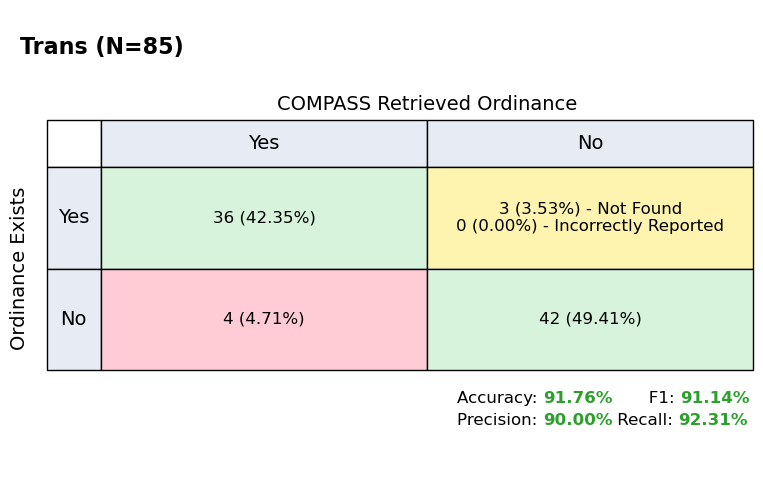

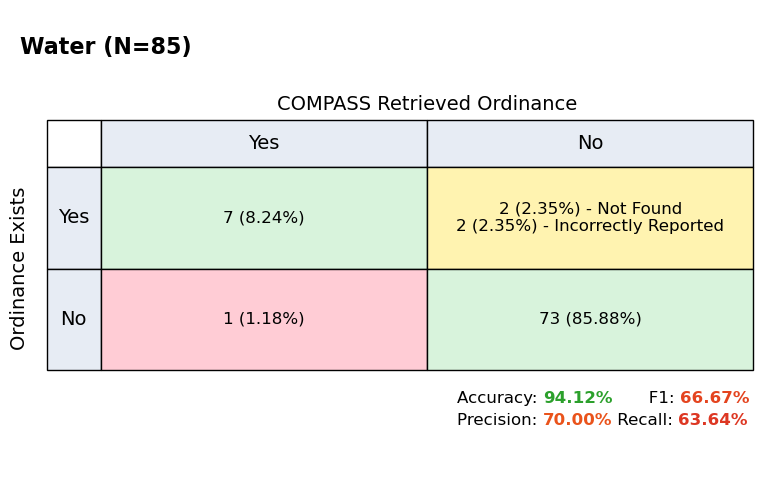

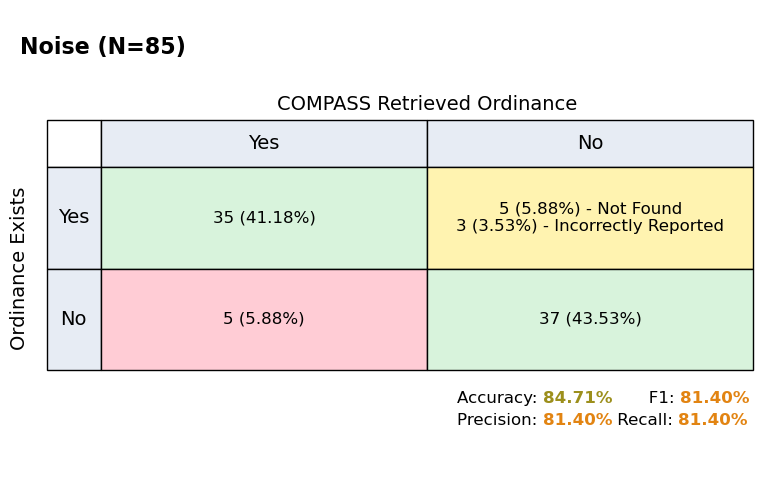

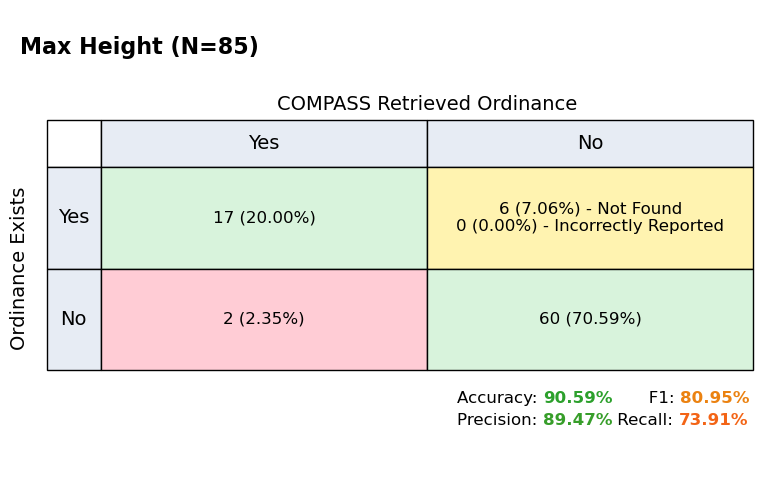

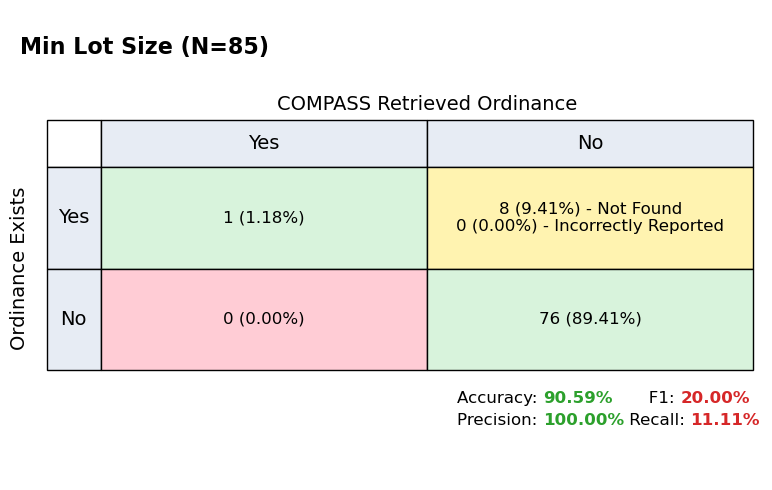

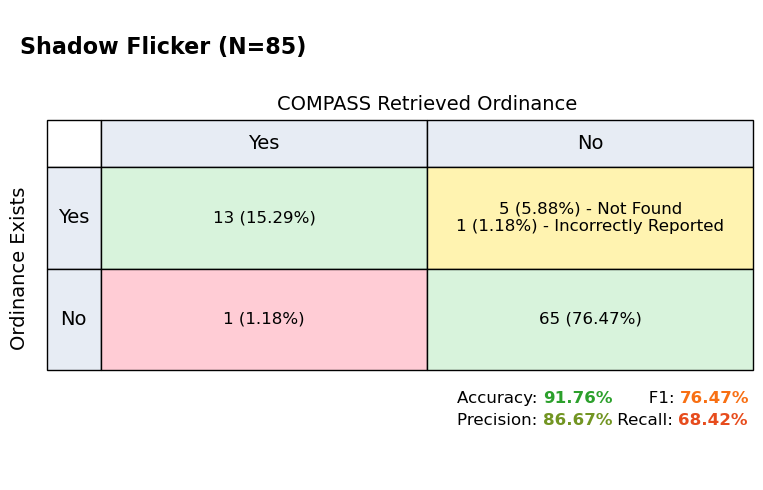

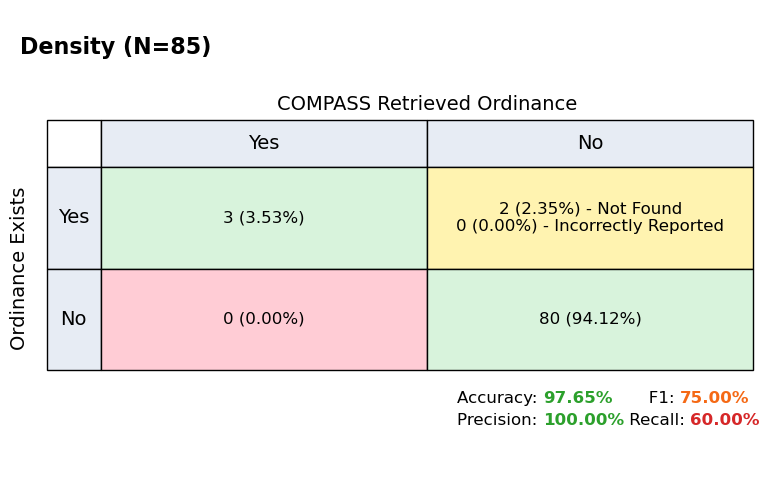

In [36]:
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    plot_out_fn = f"wind_validation_{feature}.png"
    plot_out_fn = (
        plot_out_fn.replace(" ", "_").replace("(", "").replace(")", "")
    )
    with contextlib.suppress(IndexError):
        plot_compass_confusion_matrix_from_data(
            data,
            score_cats,
            title=feature.title(),
            truth_labels_col=truth_labels_col,
            out_fp=plots_out_dir / plot_out_fn,
            color_scores=True,
        )